In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

In [15]:
df = pd.read_csv("employee_turnover.csv")
df.info()
df.head()
df.describe()
df.isnull()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


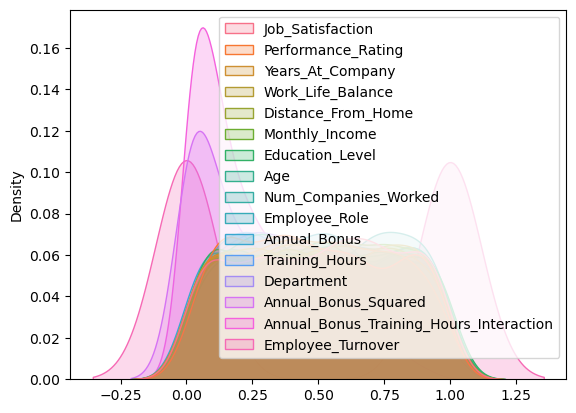

In [18]:
sns.kdeplot(data=df,  fill=True)
plt.show()

In [40]:
x=df.drop("Employee_Turnover",axis=1)
y=df["Employee_Turnover"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
model=LogisticRegression(max_iter=200)
model.fit(x_train,y_train)


LogisticRegression(max_iter=200)

In [54]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso.fit(x_train, y_train)


LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [55]:
# L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(x_train, y_train)

LogisticRegression(C=1, max_iter=200)

In [57]:
from sklearn.metrics import accuracy_score, classification_report

models = {'Baseline': model, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(x_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Baseline
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270


Lasso
Accuracy: 0.8703703703703703
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       145
           1       0.88      0.83      0.86       125

    accuracy                           0.87       270
   macro avg       0.87      0.87      0.87       270
weighted avg       0.87      0.87      0.87       270


Ridge
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg     

In [51]:
print("accuracy:",accuracy_score(y_test,y_prdict)*100)
print("precision:",precision_score(y_test,y_prdict)*100)

accuracy: 85.92592592592592
precision: 87.17948717948718
